# CNN architectures with Pytorch #

These notes are excerpted from the Rascka (M)textbook [Github](https://github.com/rasbt/machine-learning-book) under ch14.

The goal here is to decribe some of the neural network architectures that have been created to deal with image data, and show how the PyTorch library handles these structures and the related problem of loading image data.

# Loading and preprocessing the data

In [1]:
import torch
import torch.nn as nn
import torchvision 
from torchvision import transforms 
image_path = './'
transform = transforms.Compose([transforms.ToTensor()])

mnist_dataset = torchvision.datasets.MNIST(root=image_path, 
                                           train=True, 
                                           transform=transform, 
                                           download=True)

from torch.utils.data import Subset
mnist_valid_dataset = Subset(mnist_dataset, torch.arange(10000)) 
mnist_train_dataset = Subset(mnist_dataset, torch.arange(10000, len(mnist_dataset)))
mnist_test_dataset = torchvision.datasets.MNIST(root=image_path, 
                                           train=False, 
                                           transform=transform, 
                                           download=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 29.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 980kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


In [2]:
from torch.utils.data import DataLoader


batch_size = 64
torch.manual_seed(1)
train_dl = DataLoader(mnist_train_dataset, batch_size, shuffle=True)
valid_dl = DataLoader(mnist_valid_dataset, batch_size, shuffle=False)

### Implementing a CNN using the torch.nn module

#### Configuring CNN layers in PyTorch

 * **Conv2d:** `torch.nn.Conv2d`
   * `out_channels`
   * `kernel_size`
   * `stride`
   * `padding`
   
   
 * **MaxPool2d:** `torch.nn.MaxPool2d`
   * `kernel_size`
   * `stride`
   * `padding`
   
   
 * **Dropout** `torch.nn.Dropout`
   * `p`

In [9]:
model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, padding=2))
model.add_module('relu1', nn.ReLU())        
model.add_module('pool1', nn.MaxPool2d(kernel_size=2))   
model.add_module('conv2', nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2))
model.add_module('relu2', nn.ReLU())        
model.add_module('pool2', nn.MaxPool2d(kernel_size=2))      

x = torch.ones((4, 1, 28, 28))
model(x).shape

torch.Size([4, 64, 7, 7])

In [10]:
model.add_module('flatten', nn.Flatten()) 

x = torch.ones((4, 1, 28, 28))
model(x).shape

torch.Size([4, 3136])

In [11]:
model.add_module('fc1', nn.Linear(3136, 1024)) 
model.add_module('relu3', nn.ReLU()) 
model.add_module('dropout', nn.Dropout(p=0.5)) 

model.add_module('fc2', nn.Linear(1024, 10)) 

In [12]:
# device = torch.device("cuda:0")  # doing this on Euclid so no GPU
device = torch.device("cpu")

model = model.to(device) 

In [13]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train(model, num_epochs, train_dl, valid_dl):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            x_batch = x_batch.to(device) 
            y_batch = y_batch.to(device) 
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item()*y_batch.size(0)
            is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.sum().cpu()

        loss_hist_train[epoch] /= len(train_dl.dataset)
        accuracy_hist_train[epoch] /= len(train_dl.dataset)
        
        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in valid_dl:
                x_batch = x_batch.to(device) 
                y_batch = y_batch.to(device) 
                pred = model(x_batch)
                loss = loss_fn(pred, y_batch)
                loss_hist_valid[epoch] += loss.item()*y_batch.size(0) 
                is_correct = (torch.argmax(pred, dim=1) == y_batch).float() 
                accuracy_hist_valid[epoch] += is_correct.sum().cpu()

        loss_hist_valid[epoch] /= len(valid_dl.dataset)
        accuracy_hist_valid[epoch] /= len(valid_dl.dataset)
        
        print(f'Epoch {epoch+1} accuracy: {accuracy_hist_train[epoch]:.4f} val_accuracy: {accuracy_hist_valid[epoch]:.4f}')
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

torch.manual_seed(1)
num_epochs = 20
hist = train(model, num_epochs, train_dl, valid_dl)

Epoch 1 accuracy: 0.9488 val_accuracy: 0.9816
Epoch 2 accuracy: 0.9840 val_accuracy: 0.9842
Epoch 3 accuracy: 0.9881 val_accuracy: 0.9876
Epoch 4 accuracy: 0.9919 val_accuracy: 0.9884
Epoch 5 accuracy: 0.9931 val_accuracy: 0.9871
Epoch 6 accuracy: 0.9943 val_accuracy: 0.9880
Epoch 7 accuracy: 0.9950 val_accuracy: 0.9907
Epoch 8 accuracy: 0.9961 val_accuracy: 0.9901
Epoch 9 accuracy: 0.9966 val_accuracy: 0.9905
Epoch 10 accuracy: 0.9965 val_accuracy: 0.9888
Epoch 11 accuracy: 0.9969 val_accuracy: 0.9889
Epoch 12 accuracy: 0.9973 val_accuracy: 0.9914
Epoch 13 accuracy: 0.9977 val_accuracy: 0.9914
Epoch 14 accuracy: 0.9973 val_accuracy: 0.9908
Epoch 15 accuracy: 0.9977 val_accuracy: 0.9916
Epoch 16 accuracy: 0.9977 val_accuracy: 0.9916
Epoch 17 accuracy: 0.9978 val_accuracy: 0.9898
Epoch 18 accuracy: 0.9983 val_accuracy: 0.9902
Epoch 19 accuracy: 0.9981 val_accuracy: 0.9893
Epoch 20 accuracy: 0.9984 val_accuracy: 0.9909


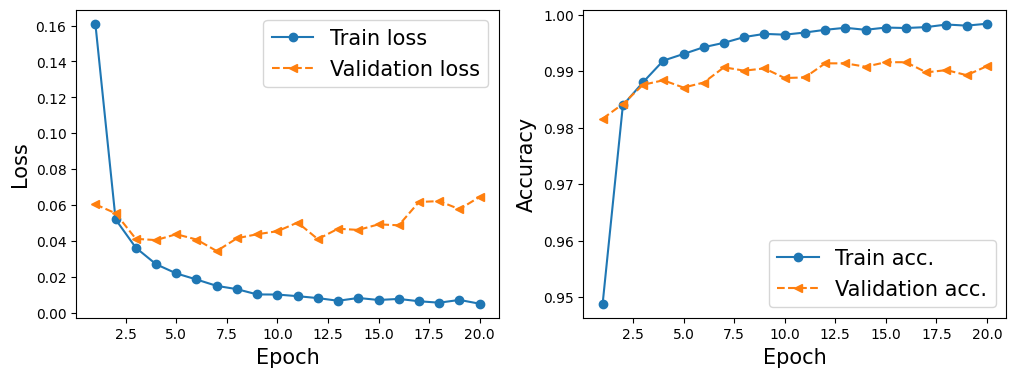

In [14]:
import matplotlib.pyplot as plt


x_arr = np.arange(len(hist[0])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist[0], '-o', label='Train loss')
ax.plot(x_arr, hist[1], '--<', label='Validation loss')
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Loss', size=15)
ax.legend(fontsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist[2], '-o', label='Train acc.')
ax.plot(x_arr, hist[3], '--<', label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)

#plt.savefig('figures/14_13.png')
plt.show()

In [15]:
torch.cuda.synchronize()
model_cpu = model.cpu()
pred = model(mnist_test_dataset.data.unsqueeze(1) / 255.)
is_correct = (torch.argmax(pred, dim=1) == mnist_test_dataset.targets).float()
print(f'Test accuracy: {is_correct.mean():.4f}') 

Test accuracy: 0.9940


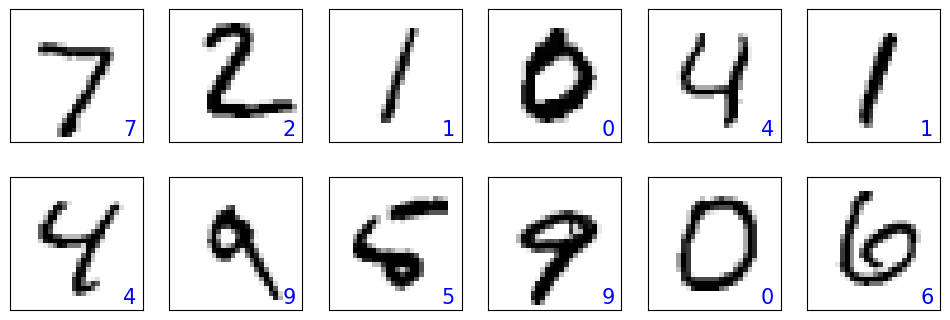

In [16]:
fig = plt.figure(figsize=(12, 4))
for i in range(12):
    ax = fig.add_subplot(2, 6, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    img = mnist_test_dataset[i][0][0, :, :]
    pred = model(img.unsqueeze(0).unsqueeze(1))
    y_pred = torch.argmax(pred)
    ax.imshow(img, cmap='gray_r')
    ax.text(0.9, 0.1, y_pred.item(), 
            size=15, color='blue',
            horizontalalignment='center',
            verticalalignment='center', 
            transform=ax.transAxes)
    
    
#plt.savefig('figures/14_14.png')
plt.show()

In [17]:
import os

if not os.path.exists('models'):
    os.mkdir('models')

path = 'models/mnist-cnn.ph'
torch.save(model, path)
 

# Pre-Trained Models and Pre-Packaged Datasets in Pytorch #

**Some Notes:** 

1. You can save your model set for future use--in particular, for use in **inference** (i.e., drawing conclusions from the data) with model.save() and model.load().

2. The pytorch package comes with several subsidiary packages for dealing with the types of data that Neural Networks are most famous for:

+ torchvision
+ torchaudio
+ torchtext

3. These packages primarily provide three things: 

+ (Well-known) Pre-trained models
+ (Pre-packaged) datasets
+ Methods for transforming those datasets

4. There are other hubs available that do similar things.  One of the most famous ones is [Huggingface](https://huggingface.co/), which specializes in Transformer and LLM models. Many of these are built on top of pytorch. 

We will do some examples with the Pytorch torchvision package.

In [7]:
import torch
import torchvision

## 1. Pre-Trained Models in Pytorch ###

### Key Point about Pytorch Pretrained models: ###

"All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be at least 224. The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225]."

### Alexnet and the Pytorch Model Hub ###

See [here](https://pytorch.org/hub/) for an overview of the Pytorch Hub and [here](https://pytorch.org/docs/stable/hub.html) for methods. **Note:** The Pytorch Hub is just a place to find models--not datasets. The Alexnet tutorial I will be following for the first part is [here](https://pytorch.org/hub/pytorch_vision_alexnet/).  You can download an .ipynb from Colab at the link. 

There are really only three methods for interacting with torch hub:

+ torch.hub.list()
+ torch.hub.help()
+ torch.hub.load()

#### List of Models on Torchvision hub ####

In [8]:
torch.hub.list('pytorch/vision')

Using cache found in /home/employee/aleahy/.cache/torch/hub/pytorch_vision_main


['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fcn_resnet101',
 'fcn_resnet50',
 'get_model_weights',
 'get_weight',
 'googlenet',
 'inception_v3',
 'lraspp_mobilenet_v3_large',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'r2plus1d_18',
 'r3d_18',
 'raft_large',
 'raft_small',
 'regnet_x_16gf',
 'regnet_x_1_6gf',
 'regnet_x_32gf',
 'regnet_x_3_2gf',
 'regnet_x_400mf',
 'regnet_x_800mf',
 'regnet_x_8gf',
 'regnet_y_128gf',
 'regnet_y_16gf',
 'regnet_y_1

#### Obtaining Information on Alexnet ####

In [9]:
print(torch.hub.help('pytorch/vision','alexnet')) # Note the syntax!

AlexNet model architecture from `One weird trick for parallelizing convolutional neural networks <https://arxiv.org/abs/1404.5997>`__.

    .. note::
        AlexNet was originally introduced in the `ImageNet Classification with
        Deep Convolutional Neural Networks
        <https://papers.nips.cc/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html>`__
        paper. Our implementation is based instead on the "One weird trick"
        paper above.

    Args:
        weights (:class:`~torchvision.models.AlexNet_Weights`, optional): The
            pretrained weights to use. See
            :class:`~torchvision.models.AlexNet_Weights` below for
            more details, and possible values. By default, no pre-trained
            weights are used.
        progress (bool, optional): If True, displays a progress bar of the
            download to stderr. Default is True.
        **kwargs: parameters passed to the ``torchvision.models.squeezenet.AlexNet``
            base cla

Using cache found in /home/employee/aleahy/.cache/torch/hub/pytorch_vision_main


#### Loading Alexnet ####

**Note:**  The model.eval() line converts the model into 'inference' mode, and disables dropout (among other things).

In [10]:
import torch
model = torch.hub.load('pytorch/vision:v0.10.0', 'alexnet', pretrained=True)
model.eval()

Using cache found in /home/employee/aleahy/.cache/torch/hub/pytorch_vision_v0.10.0


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

## 2.Transforms ##

**WARNING AGAIN:** (Mentioned above.)  "All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of shape `(3 x H x W)`, where `H` and `W` are expected to be at least `224`. The images have to be loaded in to a range of `[0, 1]` and then normalized using `mean = [0.485, 0.456, 0.406]` and `std = [0.229, 0.224, 0.225]`."

### A Sample Image for Prediction ###

In [11]:
# Download an example image from the pytorch website
import urllib
url, filename = ("https://github.com/pytorch/hub/raw/master/images/dog.jpg", "dog.jpg")
try: urllib.URLopener().retrieve(url, filename)
except: urllib.request.urlretrieve(url, filename)

### Building Datasets and Models with Transforms ###

Two points:

+ Pre-packaged Datasets are basically downloaders.  **Transforms** are a key part of getting this data into the model.  Transforms for torchvision can be found [here](https://pytorch.org/vision/0.9/transforms.html)


+ Alexnet is famous because it unequivocally won the [Imagenet competition](https://image-net.org/challenges/LSVRC/) in 2012.  The imagenet classes are [here](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).  Note there are 1000 classes, so this is not a simple task!

In [12]:
# sample execution (requires torchvision)
from PIL import Image
from torchvision import transforms
input_image = Image.open(filename)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(input_image) 
# print(input_tensor.shape)   # A test of mine - A. Leahy
input_batch = input_tensor.unsqueeze(0) # create a mini-batch as expected by the model

# move the input and model to GPU for speed if available
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    model.to('cuda')

with torch.no_grad():
    output = model(input_batch)
# Tensor of shape 1000, with confidence scores over ImageNet's 1000 classes
print(output[0])
# The output has unnormalized scores. To get probabilities, you can run a softmax on it.
probabilities = torch.nn.functional.softmax(output[0], dim=0)
print(probabilities)
print(torch.argmax(probabilities))

tensor([-1.6523e+00, -4.3462e+00, -1.8199e+00, -4.2159e+00, -3.1913e+00,
         3.3908e-01,  1.0870e+00,  5.9326e+00,  8.0356e+00, -7.0815e-01,
        -9.4468e-01, -6.0775e-01, -2.4622e-01, -1.9995e+00, -1.5297e+00,
        -3.2665e+00, -5.6068e-01,  1.0516e+00,  1.8922e-01, -4.7240e+00,
        -3.3902e+00,  4.3042e+00, -1.0984e+00,  4.6112e+00, -6.3380e-03,
        -5.3409e+00, -4.7388e+00, -3.3958e+00, -4.1289e+00,  2.9097e-01,
        -3.2948e+00, -6.7023e+00, -4.7239e+00, -4.1803e+00, -2.1845e+00,
        -2.9473e+00,  3.0487e+00, -3.5848e+00, -6.3868e+00, -4.4212e+00,
        -3.3700e+00, -5.0973e+00, -4.9044e+00, -5.5229e+00, -3.7246e+00,
        -4.0214e+00,  2.6884e-01, -4.4731e+00, -5.6616e+00, -5.4914e+00,
        -2.6848e+00, -3.2091e+00, -1.6330e+00, -5.2266e+00, -2.7492e+00,
        -2.6261e+00, -1.8175e+00, -2.3189e+00, -5.2810e+00, -3.7639e+00,
        -3.1016e+00, -4.1425e+00, -5.2537e+00, -4.6593e+00, -3.5788e+00,
        -4.0245e+00, -4.0032e+00, -4.5520e+00, -3.2

### Identifying the Category

In [4]:
# Download ImageNet labels
!wget https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt

--2024-02-25 14:53:52--  https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10472 (10K) [text/plain]
Saving to: ‘imagenet_classes.txt’

imagenet_classes.tx 100%[===================>]  10.23K  --.-KB/s    in 0s      

2024-02-25 14:53:53 (159 MB/s) - ‘imagenet_classes.txt’ saved [10472/10472]



In [5]:
# Read the categories
with open("imagenet_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]
# Show top categories per image
top5_prob, top5_catid = torch.topk(probabilities, 5)
for i in range(top5_prob.size(0)):
    print(categories[top5_catid[i]], top5_prob[i].item())

Samoyed 0.7244765162467957
wallaby 0.13937847316265106
Pomeranian 0.058749932795763016
Angora 0.02282979153096676
Arctic fox 0.012450147420167923


#### Another Approach ####

In [15]:
categories[258]

'Samoyed'